# Visual Test for data_loader_ver2

This notebook mirrors `tests/test_data_loader_ver2.py` and checks the simple 3D image/mask generator.

In [8]:
import shutil
import sys
from pathlib import Path

if Path.cwd().name == 'tests':
    sys.path.insert(0, str(Path.cwd().parent))
else:
    sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

from data_loader_ver2 import find_image_mask_pairs, load_nifti_pair, build_nifti_batch_generator

test_dir = Path('temp_test_data_ver2_notebook')
images_dir = test_dir / 'images'
masks_dir = test_dir / 'masks'

if test_dir.exists():
    shutil.rmtree(test_dir)
images_dir.mkdir(parents=True)
masks_dir.mkdir(parents=True)

print("Setup complete")


Setup complete


In [9]:
num_samples = 5
volume_shape = (32, 32, 16)

for index in range(num_samples):
    name = f"sample_{index:03d}"
    image = np.random.rand(*volume_shape).astype(np.float32)
    mask = (np.random.rand(*volume_shape) > 0.5).astype(np.uint8)

    nib.save(nib.Nifti1Image(image, np.eye(4)), images_dir / f"{name}_img.nii")
    nib.save(nib.Nifti1Image(mask, np.eye(4)), masks_dir / f"{name}_mask.nii")

print("Created fake image files:", len(list(images_dir.glob("*_img.nii"))))
print("Created fake mask files:", len(list(masks_dir.glob("*_mask.nii"))))


Created fake image files: 5
Created fake mask files: 5


In [10]:
pairs = find_image_mask_pairs(images_dir, masks_dir)
print("Pairs found:", len(pairs))
print("First image path:", pairs[0][0])
print("First mask path:", pairs[0][1])


Pairs found: 5
First image path: temp_test_data_ver2_notebook\images\sample_000_img.nii
First mask path: temp_test_data_ver2_notebook\masks\sample_000_mask.nii


In [11]:
image, mask = load_nifti_pair(*pairs[0], normalize=False)
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)


Image shape: (1, 32, 32, 16)
Mask shape: (32, 32, 16)
Image dtype: float32
Mask dtype: int64


In [12]:
batch_size = 2
generator = build_nifti_batch_generator(
    batch_size,
    images_dir=images_dir,
    masks_dir=masks_dir,
    normalize=False,
)

batch_images, batch_masks = next(generator)
print("Batch image shape:", batch_images.shape)
print("Batch mask shape:", batch_masks.shape)


Batch image shape: (2, 1, 32, 32, 16)
Batch mask shape: (2, 32, 32, 16)


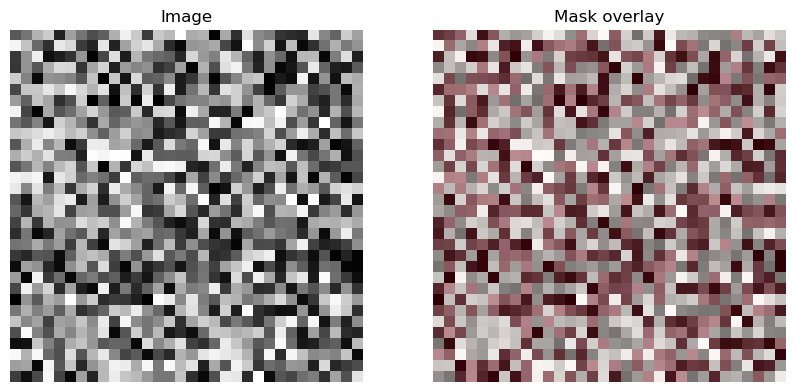

In [13]:
slice_idx = image.shape[-1] // 2
image_slice = image[0, :, :, slice_idx]
mask_slice = mask[:, :, slice_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_slice, cmap='gray')
axes[0].set_title('Image')
axes[0].axis('off')

axes[1].imshow(image_slice, cmap='gray')
axes[1].imshow(mask_slice, cmap='Reds', alpha=0.45)
axes[1].set_title('Mask overlay')
axes[1].axis('off')
plt.show()


In [14]:
CLEAN_UP = True

if CLEAN_UP and test_dir.exists():
    shutil.rmtree(test_dir)
    print("Removed", test_dir)
else:
    print("Keeping temporary files for inspection:", test_dir)


Removed temp_test_data_ver2_notebook


## 3. Integration Test with Real Data (`data.zip`)

This section runs the full pipeline: unzipping, resizing, and loading using the pure python generator. It's a more comprehensive test but takes longer to run. 

**Note:** This will only run if `data.zip` is present in the project's root directory.

In [15]:
import zipfile
from resize import resize_dataset

integration_test_dir = Path("./temp_integration_test_data_notebook")
data_zip_path = Path("../data.zip")

if not data_zip_path.exists():
    print(f"'{data_zip_path}' not found. Skipping integration test.")
else:
    # 1. Setup temporary directory
    if integration_test_dir.exists():
        shutil.rmtree(integration_test_dir)
    integration_test_dir.mkdir()
    print(f"Created temporary directory for integration test: {integration_test_dir.resolve()}")

    # 2. Unzip data.zip
    print("\nUnzipping data.zip...")
    with zipfile.ZipFile(data_zip_path, 'r') as zip_ref:
        zip_ref.extractall(integration_test_dir)
    
    raw_data_dir = integration_test_dir
    if (integration_test_dir / "data").is_dir():
        raw_data_dir = integration_test_dir / "data"
    print(f"Found raw data in: {raw_data_dir}")

    # 3. Resize the dataset
    print("\nResizing dataset...")
    resized_data_dir = integration_test_dir / "data-resize"
    resize_dims = (128, 128, 64) # Using larger dims to see more detail
    resize_dataset(
        input_dir=raw_data_dir,
        output_dir=resized_data_dir,
        dimensions=resize_dims
    )

    print(f"\nReady to use data in: {resized_data_dir}")

Created temporary directory for integration test: C:\Git\QMUL-EMS741-Extended-Projected-Group1\tests\temp_integration_test_data_notebook

Unzipping data.zip...
Found raw data in: temp_integration_test_data_notebook\data

Resizing dataset...


Resizing dataset: 100%|██████████| 589/589 [04:52<00:00,  2.02it/s]

Saved resized dataset to temp_integration_test_data_notebook\data-resize

Ready to use data in: temp_integration_test_data_notebook\data-resize


### Visualize a Real, Resized Sample

Now we can load from our newly processed data and visualize a real sample.

Successfully initialized the generator from real data.

Visualizing sample


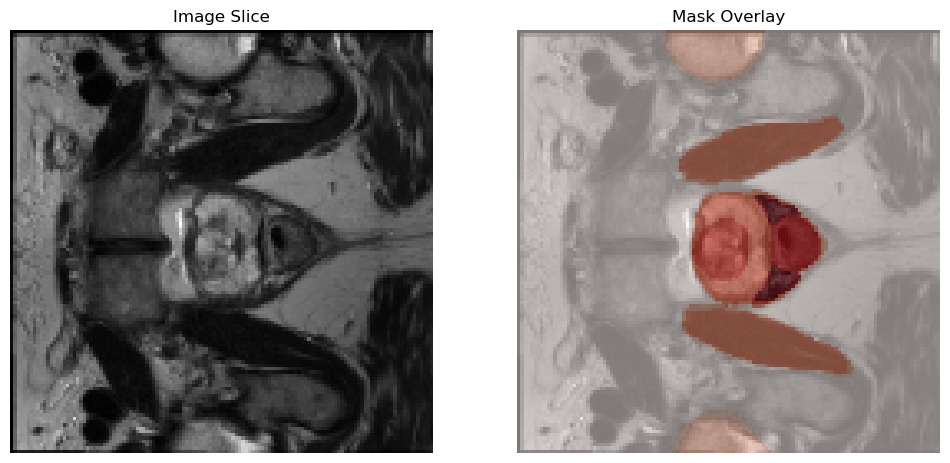


Successfully removed temporary directory: temp_integration_test_data_notebook


In [16]:
if data_zip_path.exists():
    real_generator = build_nifti_batch_generator(
        batch_size=1,
        images_dir=resized_data_dir,
        masks_dir=resized_data_dir,
        normalize=True
    )
    
    print("Successfully initialized the generator from real data.")
    
    # Get a sample
    real_batch_images, real_batch_masks = next(real_generator)
    
    print("\nVisualizing sample")
    
    # Prepare for visualization
    image_slice = real_batch_images[0, 0, :, :, resize_dims[2] // 2]
    mask_slice = real_batch_masks[0, :, :, resize_dims[2] // 2]

    # Plot the image and mask slices
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(image_slice, cmap='gray')
    axs[0].set_title("Image Slice")
    axs[0].axis('off')

    axs[1].imshow(image_slice, cmap='gray')
    axs[1].imshow(mask_slice, cmap='Reds', alpha=0.5)
    axs[1].set_title("Mask Overlay")
    axs[1].axis('off')

    plt.show()
    
    # Clean up the integration test directory
    shutil.rmtree(integration_test_dir)
    print(f"\nSuccessfully removed temporary directory: {integration_test_dir}")